In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import netCDF4 as nc
import pickle


In [2]:
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'
dataset = nc.Dataset(fname)
lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h = np.transpose(dataset.variables['h'], axes=(1, 0))
# f = np.transpose(dataset.variables['f'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))
def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
j_mid = lon_rho.shape[1] // 2
i_mid = lon_rho.shape[0] // 2
dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])
x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')


In [3]:
df_eddies = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/df_eddies_50m_vert_checked_processed.pkl')
with open('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/dic_vert_doppio_50m_vert_checked.pkl', 'rb') as f:
    dic_vert = pickle.load(f)
    

In [4]:
def quad_solver_x(xc, yc, q11, q12, q22, Rc, y0):
    a = q11
    b = -2*q11*xc + 2*q12*(y0 - yc)
    c = q11*xc**2 - 2*q12*xc*(y0 - yc) + q22*(y0 - yc)**2 - Rc**2/2

    disc = b*b - 4*a*c
    root1 = np.where(disc >= 0, (-b - np.sqrt(disc)) / (2*a), np.nan)
    root2 = np.where(disc >= 0, (-b + np.sqrt(disc)) / (2*a), np.nan)
    return root1, root2

def quad_solver_y(xc, yc, q11, q12, q22, Rc, x0):
    a = q22
    b = 2*q12*(x0 - xc)
    c = q11*(x0 - xc)**2 - Rc**2/2

    disc = b*b - 4*a*c
    dy1 = np.where(disc >= 0, (-b - np.sqrt(disc)) / (2*a), np.nan)
    dy2 = np.where(disc >= 0, (-b + np.sqrt(disc)) / (2*a), np.nan)
    return yc + dy1, yc + dy2
    

In [5]:
def plot_eddy_xy_profile(
    eddy,
    day_idx,
    df_eddies,
    dic_sample,
    x_grid,
    y_grid,
    z_r,
    h,
    quad_solver_x,
    quad_solver_y,
    r=None,
    color='r',
    base_path='/srv/scratch/z5297792/Climatology/u_v',
    figsize=(8, 4),
):
    """
    Plot x-z and y-z velocity sections for one eddy on one sampled day.

    Left:  v(x, z) at y = surface eddy centre
    Right: u(y, z) at x = surface eddy centre
    """

    eddy = int(eddy)

    row0 = df_eddies.loc[df_eddies.Eddy == eddy].iloc[0]
    cyc = row0.Cyc

    if r is None:
        r = 140

    # --- get sampled vertical eddy dataframe ---
    dic = dic_sample[f'Eddy{eddy}']
    day_key = list(dic.keys())[day_idx]
    day = int(day_key[3:])
    df = dic[day_key].copy()

    day_rel = day - row0.Day

    # --- get file name ---
    fname = df_eddies.loc[
        (df_eddies.Eddy == eddy) & (df_eddies.Day == day),
        'fname'
    ].iloc[0]

    fnumber = fname[-8:-3]

    # --- load velocity fields ---
    u_raw = np.load(f'{base_path}/u_{fnumber}.npy').astype(float)
    v_raw = np.load(f'{base_path}/v_{fnumber}.npy').astype(float)

    u_raw[np.abs(u_raw) > 1e30] = np.nan
    v_raw[np.abs(v_raw) > 1e30] = np.nan

    with nc.Dataset(fname) as dataset:
        ocean_time = dataset.variables['ocean_time'][:].data / 86400

    t_rel = np.where(ocean_time == day)[0][0]

    u_t = u_raw[:, :, :, t_rel]
    v_t = v_raw[:, :, :, t_rel]

    # --- surface centre and section indices ---
    xc_surf, yc_surf = df.iloc[0][['xc', 'yc']]

    ic = np.argmin(np.abs(x_grid - xc_surf))
    jc = np.argmin(np.abs(y_grid - yc_surf))

    x_mask = np.abs(x_grid - xc_surf) < r
    y_mask = np.abs(y_grid - yc_surf) < r

    z_km = np.abs(z_r[150, 150, :]) / 1e3
    depth_km = df.Depth.abs() / 1e3

    vmax_v = np.nanmax(np.abs(v_t[x_mask, jc, :]))
    vmax_u = np.nanmax(np.abs(u_t[ic, y_mask, :]))

    # --- figure ---
    fig, axs = plt.subplots(1, 2, figsize=figsize, sharey=True)
    ax0, ax1 = axs

    title = f'{cyc}{eddy}, Day {day_rel}'
    ax0.set_title(title)
    ax1.set_title(title)

    # ============================================================
    # x-z section: v velocity
    # ============================================================
    im0 = ax0.contourf(
        x_grid[x_mask],
        z_km,
        v_t[x_mask, jc, :].T,
        cmap='coolwarm',
        vmin=-vmax_v,
        vmax=vmax_v,
        zorder=0
    )

    ax0.plot(df.xc, depth_km, color=color)

    roots_x = np.array([
        quad_solver_x(
            d.xc,
            d.yc,
            d.Q[0, 0],
            d.Q[1, 0],
            d.Q[1, 1],
            d.Rc,
            y_grid[jc]
        )
        for _, d in df.iterrows()
    ])

    zorder_x = 1 if df.iloc[-1].yc > y_grid[jc] else 3

    ax0.plot(roots_x[:, 0], depth_km, color=color, ls='--', zorder=zorder_x)
    ax0.plot(roots_x[:, 1], depth_km, color=color, ls='--', zorder=zorder_x)

    ax0.plot(x_grid[x_mask], h[x_mask, jc] / 1e3, 'k', zorder=2)
    ax0.fill_between(
        x_grid[x_mask],
        h[x_mask, jc] / 1e3,
        10,
        color='k',
        zorder=2
    )

    ax0.set_xlabel('x (km)')
    ax0.set_ylabel('Depth (km)')

    cbar0 = fig.colorbar(im0, ax=ax0, pad=0.02, shrink=0.8)
    cbar0.set_label(r'$v$ (m s$^{-1}$)')

    ax0.set_xlim(xc_surf - r, xc_surf + r)

    # ============================================================
    # y-z section: u velocity
    # ============================================================
    im1 = ax1.contourf(
        y_grid[y_mask],
        z_km,
        u_t[ic, y_mask, :].T,
        cmap='coolwarm',
        vmin=-vmax_u,
        vmax=vmax_u,
        zorder=0
    )

    ax1.plot(df.yc, depth_km, color=color)

    roots_y = np.array([
        quad_solver_y(
            d.xc,
            d.yc,
            d.Q[0, 0],
            d.Q[1, 0],
            d.Q[1, 1],
            d.Rc,
            x_grid[ic]
        )
        for _, d in df.iterrows()
    ])

    zorder_y = 1 if df.iloc[-1].xc < x_grid[ic] else 3

    ax1.plot(roots_y[:, 0], depth_km, color=color, ls='--', zorder=zorder_y)
    ax1.plot(roots_y[:, 1], depth_km, color=color, ls='--', zorder=zorder_y)

    ax1.plot(y_grid[y_mask], h[ic, y_mask] / 1e3, 'k', zorder=2)
    ax1.fill_between(
        y_grid[y_mask],
        h[ic, y_mask] / 1e3,
        10,
        color='k',
        zorder=2
    )

    ax1.set_xlabel('y (km)')
    ax1.set_ylim(0, 5)

    cbar1 = fig.colorbar(im1, ax=ax1, pad=0.02, shrink=0.8)
    cbar1.set_label(r'$u$ (m s$^{-1}$)')

    ax1.set_xlim(yc_surf - r, yc_surf + r)

    ax0.invert_yaxis()

    plt.tight_layout()
    plt.show()

    return fig, axs
    

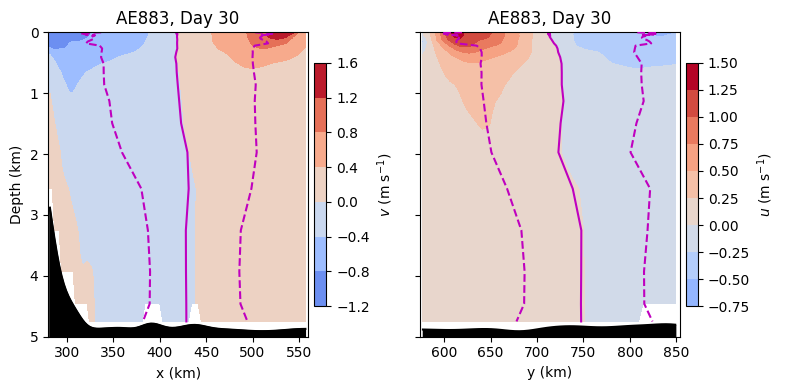

In [7]:
fig, axs = plot_eddy_xy_profile(
    eddy=883,
    day_idx=30,
    df_eddies=df_eddies,
    dic_sample=dic_vert,
    x_grid=x_grid,
    y_grid=y_grid,
    z_r=z_r,
    h=h,
    quad_solver_x=quad_solver_x,
    quad_solver_y=quad_solver_y,
    color='m'
)
